In [53]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Desafio 1

In [54]:
iris = load_iris()
x = iris.data
y = iris.target
target_names = iris.target_names

Xtrain, Xtest, Ytrain, Ytest = train_test_split(x, y, test_size=0.3, random_state=42)

mlp = MLPClassifier(hidden_layer_sizes=(3,3),
                    max_iter=5000,
                    random_state=42
                    )

mlp.fit(Xtrain,Ytrain)

MLPClassifier(hidden_layer_sizes=(3, 3), max_iter=5000, random_state=42)

In [55]:
Ypred = mlp.predict(Xtest)

accuracy = accuracy_score(Ytest, Ypred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9778


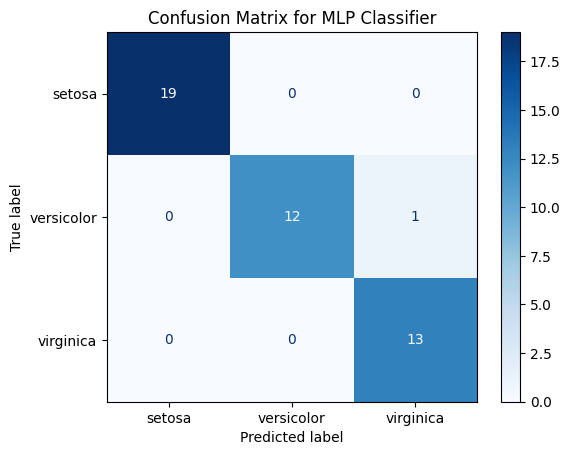

In [56]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_estimator(mlp, Xtest, Ytest, display_labels=target_names, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MLP Classifier')
plt.show()

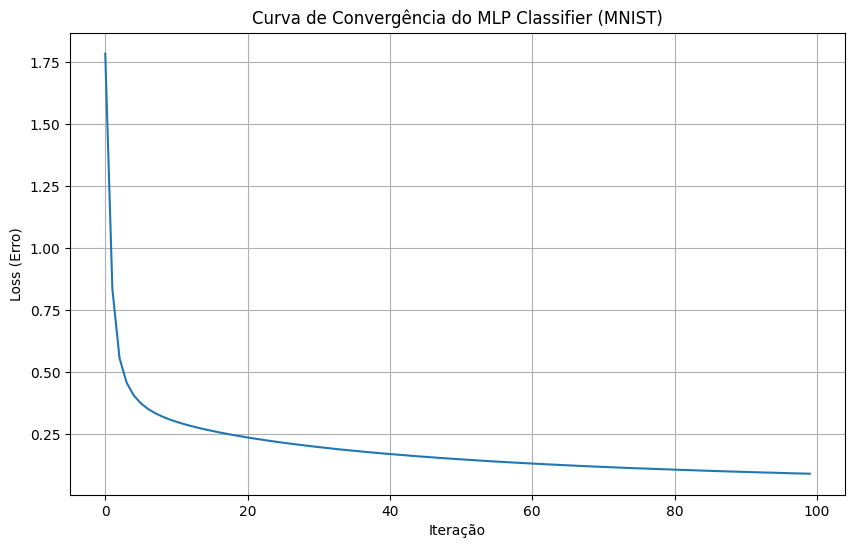

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(mlp_mnist.loss_curve_)
plt.title('Curva de Convergência do MLP Classifier (MNIST)')
plt.xlabel('Iteração')
plt.ylabel('Loss (Erro)')
plt.grid(True)
plt.show()

# Desafio 2

In [58]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mnist, y_mnist = mnist.data, mnist.target
X_mnist = X_mnist / 255.0

In [59]:
print(X_mnist)
print(y_mnist)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
['5' '0' '4' ... '4' '5' '6']


Shape of X_train_mnist: (56000, 784)
Shape of y_train_mnist: (56000,)
Shape of X_test_mnist: (14000, 784)
Shape of y_test_mnist: (14000,)
Iteration 1, loss = 1.78519276
Iteration 2, loss = 0.83617527
Iteration 3, loss = 0.55793536
Iteration 4, loss = 0.45813078
Iteration 5, loss = 0.40693576
Iteration 6, loss = 0.37475958
Iteration 7, loss = 0.35212611
Iteration 8, loss = 0.33521078
Iteration 9, loss = 0.32160680
Iteration 10, loss = 0.30992903
Iteration 11, loss = 0.30019442
Iteration 12, loss = 0.29144229
Iteration 13, loss = 0.28368031
Iteration 14, loss = 0.27639573
Iteration 15, loss = 0.26965810
Iteration 16, loss = 0.26353751
Iteration 17, loss = 0.25764287
Iteration 18, loss = 0.25205543
Iteration 19, loss = 0.24669370
Iteration 20, loss = 0.24176302
Iteration 21, loss = 0.23694657
Iteration 22, loss = 0.23231230
Iteration 23, loss = 0.22807911
Iteration 24, loss = 0.22372640
Iteration 25, loss = 0.21975529
Iteration 26, loss = 0.21577532
Iteration 27, loss = 0.21213089
Iterati

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


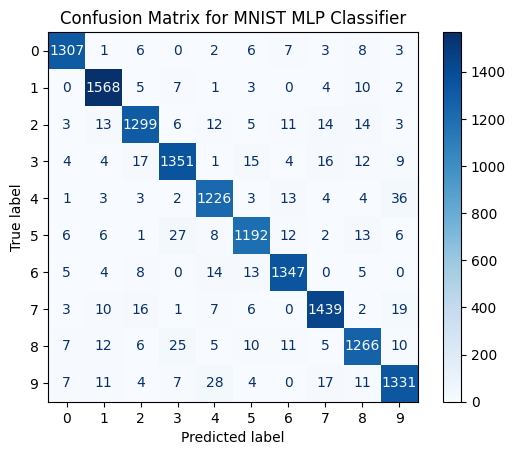

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(X_mnist, y_mnist, test_size=0.2, random_state=42)

print(f"Shape of X_train_mnist: {X_train_mnist.shape}")
print(f"Shape of y_train_mnist: {y_train_mnist.shape}")
print(f"Shape of X_test_mnist: {X_test_mnist.shape}")
print(f"Shape of y_test_mnist: {y_test_mnist.shape}")

mlp_mnist = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=50, alpha=1e-4, solver='sgd', verbose=10, random_state=42)
mlp_mnist.fit(X_train_mnist, y_train_mnist)

y_pred_mnist = mlp_mnist.predict(X_test_mnist)

accuracy_mnist = accuracy_score(y_test_mnist, y_pred_mnist)
print(f"\nAccuracy for MNIST MLP Classifier: {accuracy_mnist:.4f}")

disp_mnist = ConfusionMatrixDisplay.from_estimator(mlp_mnist, X_test_mnist, y_test_mnist, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MNIST MLP Classifier')
plt.show()

# Desafio 3

In [61]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.
Path to dataset files: /kaggle/input/human-activity-recognition-with-smartphones


In [62]:
import os
import pandas as pd


print(f"Contents of {path}:")
for filename in os.listdir(path):
    print(filename)

train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))

print('\nFirst 5 rows of train_df:')
print(train_df.head())

print('\nFirst 5 rows of test_df:')
print(test_df.head())

Contents of /kaggle/input/human-activity-recognition-with-smartphones:
train.csv
test.csv

First 5 rows of train_df:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.9808

In [63]:
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train_har = train_df.drop(['subject', 'Activity'], axis=1)
y_train_har = train_df['Activity']

X_test_har = test_df.drop(['subject', 'Activity'], axis=1)
y_test_har = test_df['Activity']

label_encoder = LabelEncoder()
y_train_har_encoded = label_encoder.fit_transform(y_train_har)
y_test_har_encoded = label_encoder.transform(y_test_har)

print(f"Shape of X_train_har: {X_train_har.shape}")
print(f"Shape of y_train_har_encoded: {y_train_har_encoded.shape}")
print(f"Shape of X_test_har: {X_test_har.shape}")
print(f"Shape of y_test_har_encoded: {y_test_har_encoded.shape}")

activity_names = label_encoder.classes_

Shape of X_train_har: (7352, 561)
Shape of y_train_har_encoded: (7352,)
Shape of X_test_har: (2947, 561)
Shape of y_test_har_encoded: (2947,)


In [64]:
mlp_har = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=300,
    alpha=0.0001,
    solver='adam',
    verbose=True,
    random_state=42
)

mlp_har.fit(X_train_har, y_train_har_encoded)

Iteration 1, loss = 0.83210982
Iteration 2, loss = 0.32220132
Iteration 3, loss = 0.22134521
Iteration 4, loss = 0.16922692
Iteration 5, loss = 0.13858246
Iteration 6, loss = 0.11945207
Iteration 7, loss = 0.09755008
Iteration 8, loss = 0.08518718
Iteration 9, loss = 0.07706746
Iteration 10, loss = 0.07452892
Iteration 11, loss = 0.07582951
Iteration 12, loss = 0.06192664
Iteration 13, loss = 0.05774428
Iteration 14, loss = 0.05784231
Iteration 15, loss = 0.05557560
Iteration 16, loss = 0.06675497
Iteration 17, loss = 0.05882532
Iteration 18, loss = 0.04523020
Iteration 19, loss = 0.04661061
Iteration 20, loss = 0.04441453
Iteration 21, loss = 0.04281406
Iteration 22, loss = 0.04511526
Iteration 23, loss = 0.04329464
Iteration 24, loss = 0.04010530
Iteration 25, loss = 0.04380150
Iteration 26, loss = 0.04990652
Iteration 27, loss = 0.03958702
Iteration 28, loss = 0.03798084
Iteration 29, loss = 0.03389274
Iteration 30, loss = 0.03661470
Iteration 31, loss = 0.05600645
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42,
              verbose=True)

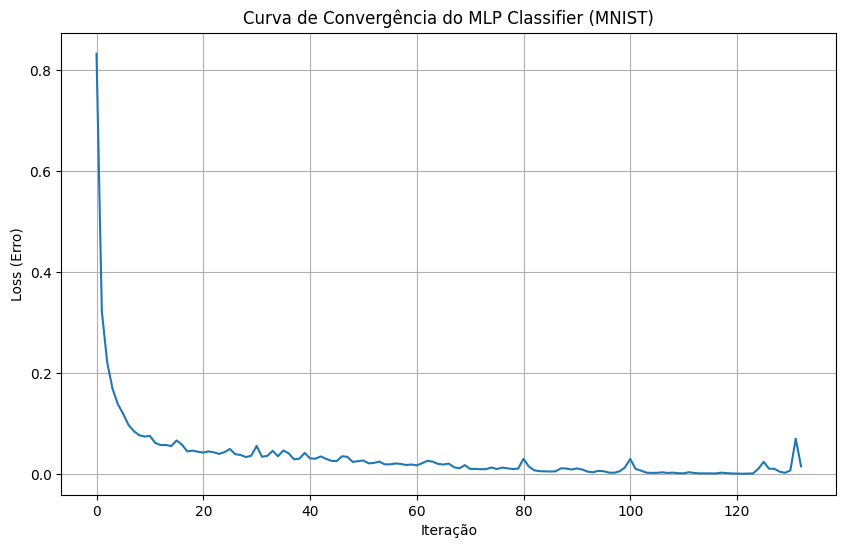

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(mlp_har.loss_curve_)
plt.title('Curva de Convergência do MLP Classifier (MNIST)')
plt.xlabel('Iteração')
plt.ylabel('Loss (Erro)')
plt.grid(True)
plt.show()


Accuracy for Human Activity Recognition MLP Classifier: 0.9515


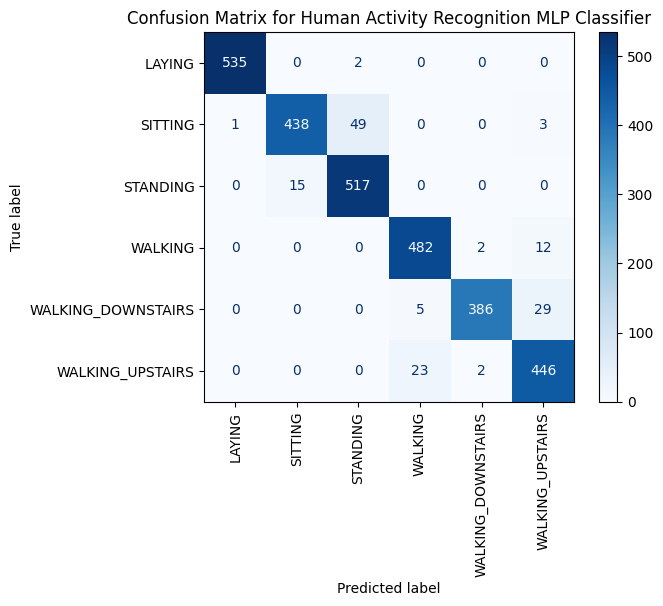

In [66]:
# Make predictions on the test set
y_pred_har_encoded = mlp_har.predict(X_test_har)

# Evaluate the model
accuracy_har = accuracy_score(y_test_har_encoded, y_pred_har_encoded)
print(f"\nAccuracy for Human Activity Recognition MLP Classifier: {accuracy_har:.4f}")

# Plot Confusion Matrix
disp_har = ConfusionMatrixDisplay.from_estimator(
    mlp_har,
    X_test_har,
    y_test_har_encoded,
    display_labels=activity_names,
    cmap=plt.cm.Blues,
    xticks_rotation='vertical'
)
plt.title('Confusion Matrix for Human Activity Recognition MLP Classifier')
plt.show()